Importing the libraries for data manipulation

In [2]:
import numpy as np
import pandas as pd

Data Manipulation Process
1. Check the data.
2. Update according to the needs.

In [4]:
df = pd.read_csv('data/reporte_cruceros_revenue_management.csv')

In [5]:
df.head()

,RES_ID,Fecha_Viaje,Fecha_Reserva,Lead_Time_Dias,Noches_Estancia,Barco,Compañia,Tipo_Ruta,Suite_Type,Booking_Source,Package,Guest_Country,Cabinas_Totales_Barco,Cabinas_Reservadas,Porcentaje_Ocupacion_Ciclo,Pasajeros_Reserva,Tripulacion,Ingreso_Total_Reserva_USD,Gasto_Promedio_Diario_Huesped_USD,Puntuacion_Satisfaccion
0,RES-00001,2018-01-05,2017-08-18,140,6,MSC World Europa,MSC Cruceros,Mediterráneo,Balcony,Direct,All Inclusive,USA,2626,1,87.12,2,2138,2762.28,147.39,4.4
1,RES-00002,2018-01-05,2017-09-14,113,6,MSC World Europa,MSC Cruceros,Mediterráneo,Interior,B2B,All Inclusive + EXC,Spain,2626,1,87.12,1,2138,1863.06,144.91,4.3
2,RES-00003,2018-01-05,2017-11-01,65,6,MSC World Europa,MSC Cruceros,Mediterráneo,Oceanview,Web,All Inclusive,Germany,2626,1,87.12,2,2138,2760.48,147.24,4.6
3,RES-00004,2018-01-05,2017-10-31,66,6,MSC World Europa,MSC Cruceros,Mediterráneo,Interior,Web,All Inclusive + EXC,USA,2626,2,87.12,2,2138,3883.68,158.04,4.3
4,RES-00005,2018-01-05,2017-09-17,110,6,MSC World Europa,MSC Cruceros,Mediterráneo,Oceanview,Direct,All Inclusive + EXC,USA,2626,1,87.12,2,2138,2723.28,144.14,4.3


In [6]:
df = df.drop(columns=['RES_ID'])

In [7]:
df["Fecha_Viaje"] = pd.to_datetime(df["Fecha_Viaje"])

In [8]:
df["Year"] = df["Fecha_Viaje"].dt.year
df["Month"] = df["Fecha_Viaje"].dt.month
df["Day"] = df["Fecha_Viaje"].dt.day
df["DayOfWeek"] = df["Fecha_Viaje"].dt.dayofweek
df["Quarter"] = df["Fecha_Viaje"].dt.quarter

In [9]:
df["Fecha_Reserva"] = pd.to_datetime(df["Fecha_Reserva"])

In [10]:
df["Year_Reserva"] = df["Fecha_Reserva"].dt.year
df["Month_Reserva"] = df["Fecha_Reserva"].dt.month
df["Day_Reserva"] = df["Fecha_Reserva"].dt.day
df["DayOfWeek_Reserva"] = df["Fecha_Reserva"].dt.dayofweek
df["Quarter_Reserva"] = df["Fecha_Reserva"].dt.quarter

In [11]:
df = df.drop(columns=['Fecha_Viaje', 'Fecha_Reserva'])

In [12]:
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [13]:
y = df["Puntuacion_Satisfaccion"]
X = df.drop(columns=["Puntuacion_Satisfaccion"])


Import the necessary ML training algorithm

In [14]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Import XGboost Regressor

In [15]:
from xgboost import XGBRegressor

In [16]:
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Using metrices for finding the accuracy

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, model.predict(X_test))
mse = mean_squared_error(y_test, model.predict(X_test))
rmse = np.sqrt(mse)
r2 = r2_score(y_test, model.predict(X_test))

In [18]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2 Score: {r2}")

Mean Absolute Error: 0.10878753550698828
Mean Squared Error: 0.018560833394158264
Root Mean Squared Error: 0.13623814955495492
R2 Score: 0.7422748348752446


In [19]:
print(df["Puntuacion_Satisfaccion"].describe())

count    77040.000000
mean         4.583586
std          0.268580
min          3.700000
25%          4.400000
50%          4.600000
75%          4.800000
max          5.000000
Name: Puntuacion_Satisfaccion, dtype: float64


Feature importance

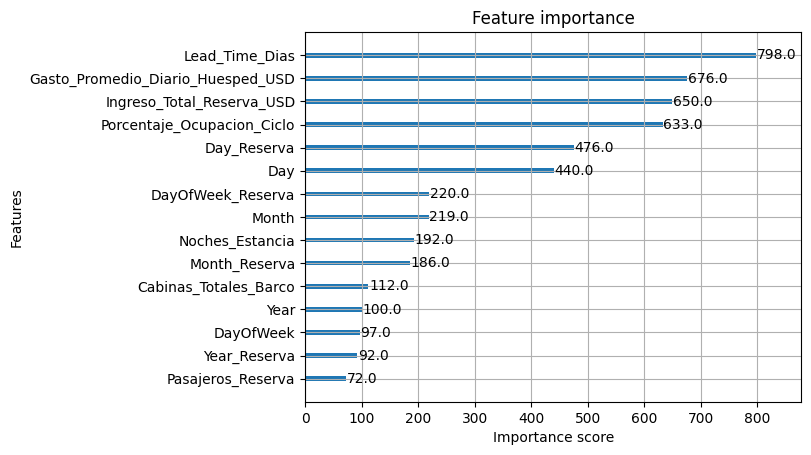

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=15)
plt.show()

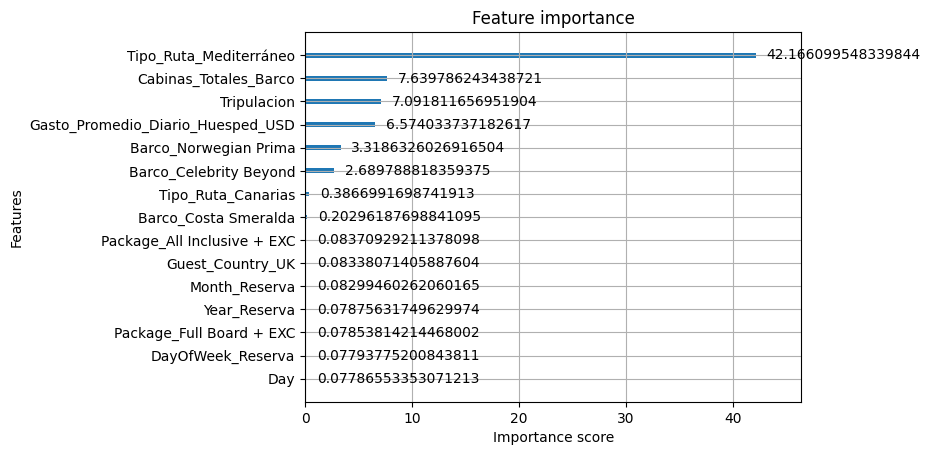

In [21]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, importance_type="gain", max_num_features=15)
plt.show()

In [22]:
import shap

explainer = shap.Explainer(model)

shap_values = explainer.shap_values(X_test)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


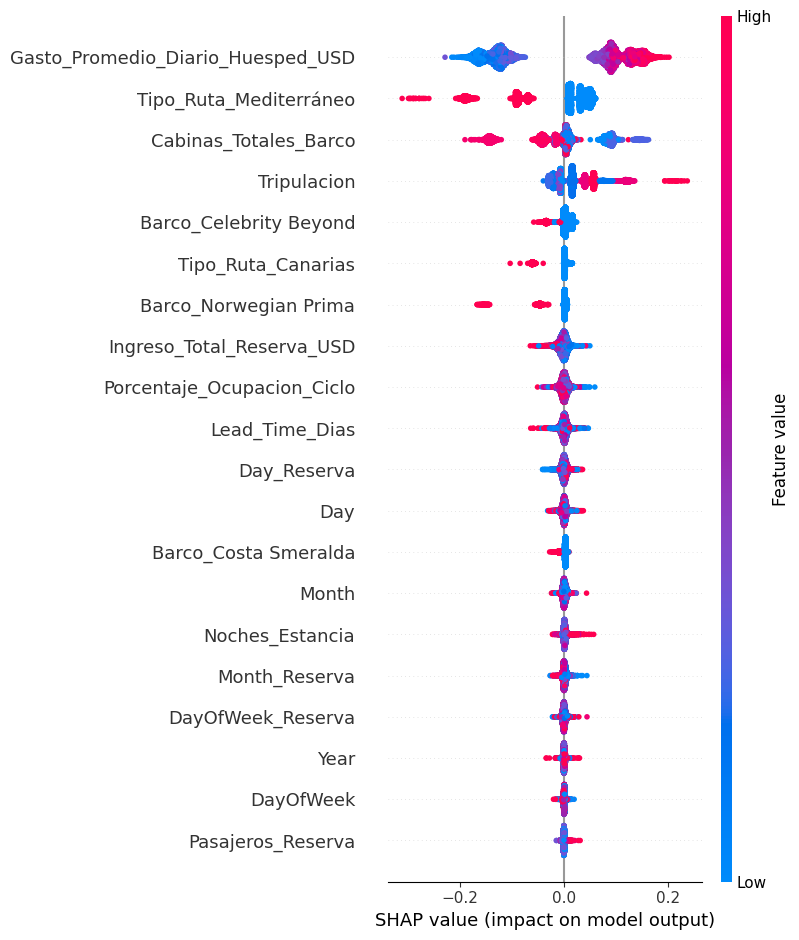

In [23]:
shap.summary_plot(shap_values, X_test)

In [24]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

model = XGBRegressor(random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.73368548 0.73606519 0.73337367 0.73796181 0.73217981]
0.734653191538952


Waterfall Plot

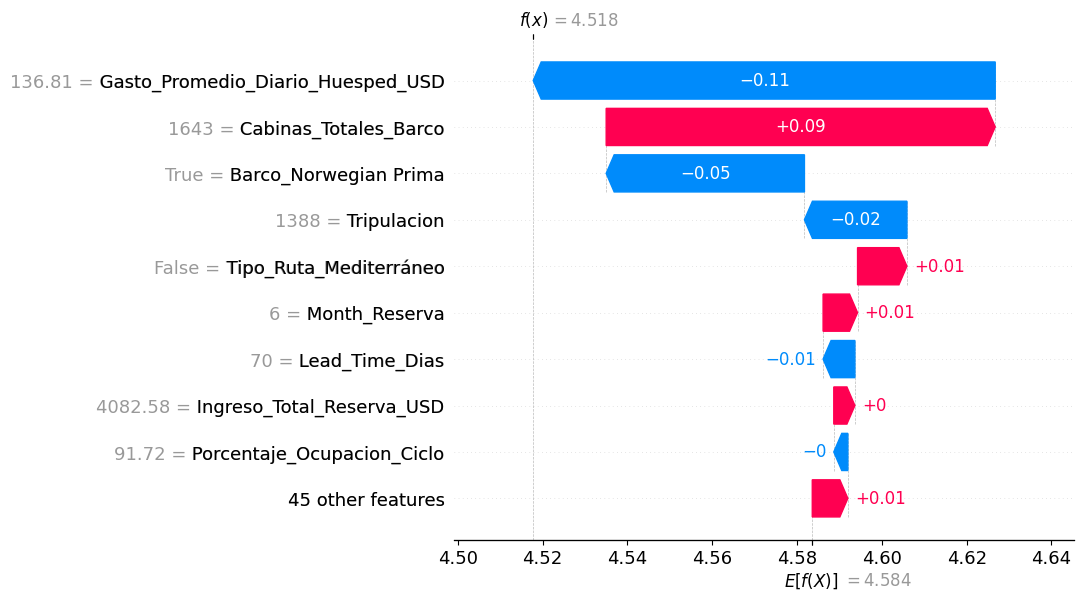

In [25]:
shap.plots.waterfall(
    explainer(X_test.iloc[[0]])[0]
)

Dependence Plot

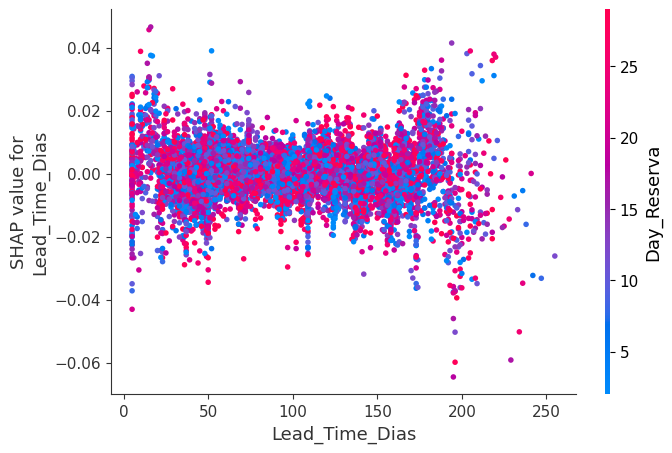

In [26]:
shap.dependence_plot(
    "Lead_Time_Dias",
    shap_values,
    X_test
)